In [6]:
# CELL R.2 - Repair src/project_setup.py (run BEFORE any header cell)
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path

SRC = Path('/content/drive/MyDrive/xray-classifier/src')
f = SRC / "project_setup.py"
txt = f.read_text()

bad  = 'f.write("\n" + "".join(new))'    # normal string: contains a REAL line break (the broken text)
good = r'f.write("\n" + "".join(new))'   # raw string: keeps backslash-n as two characters

print("Broken text found:", txt.count(bad))
if txt.count(bad) == 1:
    f.write_text(txt.replace(bad, good))
    print("Repaired.")

for p in sorted(SRC.glob("*.py")):
    compile(p.read_text(), str(p), "exec")
    print("OK:", p.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Broken text found: 1
Repaired.
OK: project_setup.py
OK: xray_data.py


In [7]:
# CELL 3.1 - Standard header
from google.colab import drive, userdata
drive.mount('/content/drive')
import sys
sys.path.insert(0, '/content/drive/MyDrive/xray-classifier/src')
from project_setup import *

import shutil, importlib
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import StratifiedGroupKFold

set_seed()
CONFIG = load_config()
FIG = PATHS["docs"] / "figures"
print("Ready. Device:", DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready. Device: cuda


In [8]:
# CELL 3.2 - Patient-level, stratified split (about 70/15/15)
df = pd.read_csv(PATHS["processed"] / "metadata.csv")
df = df.rename(columns={"split": "orig_split"})   # keep the leaky original for reference

df["target"] = (df.label == "PNEUMONIA").astype(int)          # 1 = pneumonia (positive class)
df["strat"] = df.subtype.fillna("normal")                      # normal / bacteria / virus
df["cache_name"] = df.label + "__" + df.filename.str.replace(r"\.\w+$", "", regex=True) + ".png"

assert df.cache_name.is_unique
assert (df.groupby("patient_id").label.nunique() == 1).all()   # each patient has one label

# Step 1: carve out the test set (1 of 7 folds, about 14%)
sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
trainval_idx, test_idx = next(sgkf.split(df, df.strat, groups=df.patient_id))
trainval = df.iloc[trainval_idx]

# Step 2: carve the validation set from the rest (1 of 6 folds, about 14% of total)
sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
_, val_idx = next(sgkf2.split(trainval, trainval.strat, groups=trainval.patient_id))

df["partition"] = "train"
df.loc[trainval.index[val_idx], "partition"] = "val"
df.loc[df.index[test_idx], "partition"] = "test"
print(df.partition.value_counts())

partition
train    4177
val       871
test      808
Name: count, dtype: int64


In [9]:
# CELL 3.3 - Verify and save
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    shared = set(df[df.partition == a].patient_id) & set(df[df.partition == b].patient_id)
    assert len(shared) == 0, f"Leak between {a} and {b}: {len(shared)} patients"
print("No patient appears in more than one partition.\n")

summary = pd.DataFrame({
    "images": df.groupby("partition").size(),
    "patients": df.groupby("partition").patient_id.nunique(),
    "pneumonia_%": (df.groupby("partition").target.mean() * 100).round(1),
    "virus_%": (df.groupby("partition").apply(lambda g: (g.subtype == "virus").mean()) * 100).round(1),
})
print(summary)

keep = ["cache_name", "filename", "label", "subtype", "patient_id", "target", "partition"]
df[keep].to_csv(PATHS["configs"] / "splits.csv", index=False)
print("\nSaved configs/splits.csv")

No patient appears in more than one partition.

           images  patients  pneumonia_%  virus_%
partition                                        
test          808       407         70.8     25.7
train        4177      1980         73.2     25.9
val           871       403         73.9     23.2


/tmp/ipykernel_1923/228544144.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "virus_%": (df.groupby("partition").apply(lambda g: (g.subtype == "virus").mean()) * 100).round(1),



Saved configs/splits.csv


In [ ]:
# CELL 3.4 - Resize once to 256x256 grayscale and cache
CACHE = PATHS["processed"] / "img256"
CACHE.mkdir(parents=True, exist_ok=True)

for _, r in tqdm(df.iterrows(), total=len(df)):
    out = CACHE / r.cache_name
    if out.exists():
        continue
    with Image.open(r.path) as im:
        im.convert("L").resize((256, 256), Image.Resampling.LANCZOS).save(out)
print("Cached images:", len(list(CACHE.glob("*.png"))))

  0%|          | 0/5856 [00:00<?, ?it/s]

Cached images: 5856


In [10]:
# CELL 3.5 - src/xray_data.py: dataset, transforms, loaders
module = '''
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

LABEL2ID = {"NORMAL": 0, "PNEUMONIA": 1}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class XrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(self.img_dir / row.cache_name).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, int(row.target)

def get_transforms(img_size=224):
    norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        transforms.ColorJitter(brightness=0.15, contrast=0.15),
        transforms.ToTensor(),
        norm,
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        norm,
    ])
    return train_tf, eval_tf

def make_loaders(splits_df, img_dir, img_size=224, batch_size=32, num_workers=2, seed=42):
    train_tf, eval_tf = get_transforms(img_size)
    g = torch.Generator().manual_seed(seed)
    loaders = {}
    for part in ["train", "val", "test"]:
        d = splits_df[splits_df.partition == part]
        ds = XrayDataset(d, img_dir, train_tf if part == "train" else eval_tf)
        loaders[part] = DataLoader(
            ds, batch_size=batch_size, shuffle=(part == "train"),
            num_workers=num_workers, pin_memory=True,
            generator=g if part == "train" else None,
        )
    return loaders
'''
(PATHS["src"] / "xray_data.py").write_text(module)
print("Wrote src/xray_data.py")

Wrote src/xray_data.py


In [ ]:
# CELL 3.6 - Copy cache to fast local disk, build loaders, check a batch
LOCAL = Path("/content/img256")
if not LOCAL.exists():
    shutil.copytree(CACHE, LOCAL)

import xray_data
importlib.reload(xray_data)

splits = pd.read_csv(PATHS["configs"] / "splits.csv")
loaders = xray_data.make_loaders(splits, LOCAL, CONFIG["img_size"], CONFIG["batch_size"], seed=SEED)

xb, yb = next(iter(loaders["train"]))
print("Batch of images:", tuple(xb.shape), xb.dtype)
print("Batch of labels:", tuple(yb.shape), "| pneumonia share in this batch:", round(yb.float().mean().item(), 2))
print({k: len(v.dataset) for k, v in loaders.items()})

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch of images: (32, 3, 224, 224) torch.float32
Batch of labels: (32,) | pneumonia share in this batch: 0.81
{'train': 4177, 'val': 871, 'test': 808}


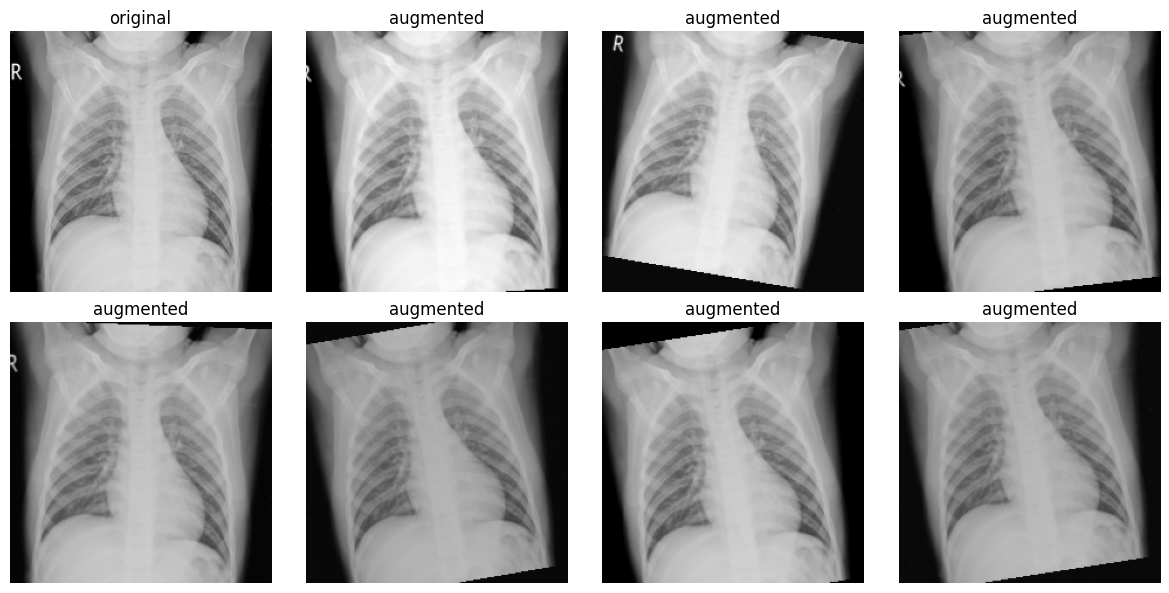

In [ ]:
# CELL 3.7 - Visualize augmentation
train_tf, _ = xray_data.get_transforms(CONFIG["img_size"])
first = splits[splits.partition == "train"].cache_name.iloc[0]
img = Image.open(LOCAL / first).convert("RGB")

mean = torch.tensor(xray_data.IMAGENET_MEAN)[:, None, None]
std = torch.tensor(xray_data.IMAGENET_STD)[:, None, None]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes[0, 0].imshow(img.resize((224, 224))); axes[0, 0].set_title("original")
for ax in axes.flat[1:]:
    t = train_tf(img) * std + mean          # undo normalization to display
    ax.imshow(t.clamp(0, 1).permute(1, 2, 0).numpy())
    ax.set_title("augmented")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout(); plt.savefig(FIG / "augmentations.png", dpi=150); plt.show()

In [ ]:
# CELL 3.7b - Fix: use bilinear interpolation in RandomAffine
f = PATHS["src"] / "xray_data.py"
txt = f.read_text()

old_imp = "from torchvision import transforms\n"
new_imp = "from torchvision import transforms\nfrom torchvision.transforms import InterpolationMode\n"
old_aff = "transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),"
new_aff = ("transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05),\n"
           "                                interpolation=InterpolationMode.BILINEAR),")
assert old_imp in txt and old_aff in txt, "Expected text not found, send me the file"
f.write_text(txt.replace(old_imp, new_imp).replace(old_aff, new_aff))

with open(PATHS["docs"] / "decision_log.md", "a") as fh:
    fh.write("""
## Decision 20 (update): Switched augmentation interpolation to bilinear
- Evidence: visual check of augmented samples showed jagged, stair-stepped edges (RandomAffine defaults to nearest-neighbor)
- Why: interpolation artifacts are not real anatomy and could become learnable noise
- Interview one-liner: "I visually inspected augmented images before training and caught an interpolation artifact."
""")
print("Patched and logged. Now rerun cells 3.6 and 3.7.")

Patched and logged. Now rerun cells 3.6 and 3.7.


In [ ]:
# CELL 3.8 - Decisions for Phase 3
counts = df.partition.value_counts().to_dict()
entries = f"""
## Decision 14: Re-split by patient, stratified on normal/bacteria/virus
- Evidence: 264 patients were shared between the original train and test folders
- Result: images per partition = {counts}; zero patients shared across partitions (asserted in code)
- Why: prevents leakage; stratifying on subtype keeps harder viral cases evenly spread
- Alternative rejected: using the provided splits (leaky, and class balance differed per split)
- Interview one-liner: "The original split leaked patients, so I rebuilt it at patient level and verified it with an assertion."

## Decision 15: Save the split to configs/splits.csv
- Why: every experiment uses identical data, and anyone can reproduce results
- Interview one-liner: "The split is a versioned file, not something regenerated on each run."

## Decision 16: PNEUMONIA is the positive class (label 1)
- Why: recall/sensitivity then means "fraction of pneumonia cases caught", matching the clinical goal

## Decision 17: Pre-resize to 256x256 grayscale PNG cache
- Why: original images are about 1300x970; reading them each epoch from Drive is slow. Resizing once is deterministic and much faster
- Alternative rejected: resizing on the fly every epoch

## Decision 18: Resize directly to 224x224 (no center crop)
- Why: lungs sit near the image edges, so cropping could cut off anatomy; a consistent squash is applied identically in train and test
- Alternative to test later: pad to square instead of squashing

## Decision 19: ImageNet mean/std normalization
- Why: Phase 5 uses ImageNet-pretrained weights, which expect inputs scaled this way

## Decision 20: Mild augmentation, no horizontal flip
- Why: small rotation/shift/zoom mimic positioning differences; brightness/contrast mimic exposure differences between machines. Flipping puts the heart on the wrong side, which is anatomically unrealistic
- Interview one-liner: "I chose augmentations that match real variation in X-ray acquisition and avoided ones that create impossible anatomy."
"""
with open(PATHS["docs"] / "decision_log.md", "a") as f:
    f.write(entries)
print("Appended decisions 14-20.")

Appended decisions 14-20.


In [ ]:
# CELL 3.10 - How well can image shape ALONE predict the class?
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix

df["aspect"] = df.width / df.height
feats = ["width", "height", "aspect"]

tr = df[df.partition == "train"]
va = df[df.partition == "val"]      # validation only; the test set stays untouched

clf = GradientBoostingClassifier(n_estimators=100, max_depth=2, random_state=SEED)
clf.fit(tr[feats], tr.target)

prob = clf.predict_proba(va[feats])[:, 1]
pred = (prob >= 0.5).astype(int)

print("Geometry-only AUROC:", round(roc_auc_score(va.target, prob), 3))
print("Geometry-only recall (pneumonia):", round(recall_score(va.target, pred), 3))
print("Accuracy:", round((pred == va.target).mean(), 3),
      "| always-guess-pneumonia accuracy:", round(va.target.mean(), 3))
print("Confusion matrix (rows=true, cols=predicted):\n", confusion_matrix(va.target, pred))
print("\nMedian size by class:\n", df.groupby("label")[["width", "height", "aspect"]].median().round(2))

Geometry-only AUROC: 0.925
Geometry-only recall (pneumonia): 0.907
Accuracy: 0.86 | always-guess-pneumonia accuracy: 0.739
Confusion matrix (rows=true, cols=predicted):
 [[165  62]
 [ 60 584]]

Median size by class:
             width  height  aspect
label                            
NORMAL     1654.0  1323.0    1.23
PNEUMONIA  1160.0   776.0    1.49


In [ ]:
# CELL 3.11 - Update Decision 13 with the real findings
med = df.groupby("label")[["width", "height"]].median().round(0).to_dict("index")
auc = round(roc_auc_score(va.target, prob), 3)

entry = f"""
## Decision 13 (update): Shortcut check found real geometry and annotation differences
- Evidence: median width/height by class = {med}
- Evidence: a classifier using ONLY width, height and aspect ratio reaches validation AUROC = {auc}
- Evidence: sample images show burned-in text ("A-P", "R" markers, technique labels) and different framing, more often on PNEUMONIA images (small sample, 4 per class)
- Why it matters: a model could score well by recognizing the acquisition source rather than lung disease
- Plan: (a) treat the geometry-only AUROC as the floor the CNN must clearly beat, (b) inspect Grad-CAM heatmaps, (c) run an occlusion test masking corners/text regions, (d) report results with this caveat
- Interview one-liner: "I found that image size alone separated the classes, so I measured how much a geometry-only model could cheat and used that as the baseline to beat."
"""
with open(PATHS["docs"] / "decision_log.md", "a") as f:
    f.write(entry)
print("Decision 13 update appended.")

Decision 13 update appended.


In [ ]:
# CELL 3.9 - Push Phase 3
git_push("Phase 3: patient-level split, data pipeline, decisions",
         userdata.get("GITHUB_USERNAME"),
         userdata.get("GITHUB_TOKEN"))

[main 5dd72c9] Phase 3: patient-level split, data pipeline, decisions
 10 files changed, 34 insertions(+), 4 deletions(-)
 create mode 100644 docs/results/geometry_baseline.json
 delete mode 100644 notebooks/00_setup Pneumonia cls.ipynb
 create mode 100644 notebooks/00_setup.ipynb
 create mode 100644 notebooks/03_split_preprocessing

To https://github.com/AbhimanyuNair/xray-classifier.git
   01ec2c3..5dd72c9  HEAD -> main



In [ ]:
# CELL 3.12 - Save geometry-only baseline result
import json
res_dir = PATHS["docs"] / "results"
res_dir.mkdir(exist_ok=True)
with open(res_dir / "geometry_baseline.json", "w") as fh:
    json.dump({
        "model": "geometry-only (width, height, aspect)",
        "val_auroc": float(auc),
        "val_recall": float(recall_score(va.target, pred)),
        "val_accuracy": float((pred == va.target).mean()),
    }, fh, indent=2)
print(open(res_dir / "geometry_baseline.json").read())

{
  "model": "geometry-only (width, height, aspect)",
  "val_auroc": 0.925,
  "val_recall": 0.906832298136646,
  "val_accuracy": 0.8599311136624569
}


In [ ]:
# CELL 3.13 - Phase 3 audit (read-only: no changes)
import re, subprocess, json
import pandas as pd
from collections import Counter

fails = []
def check(name, cond, detail=""):
    print(f"[{'PASS' if cond else 'FAIL'}] {name} {detail}")
    if not cond:
        fails.append(name)

# --- 1. Files ---
print("--- 1. Files ---")
expected = [
    PROJECT_DIR / "README.md", PROJECT_DIR / ".gitignore",
    PATHS["src"] / "project_setup.py", PATHS["src"] / "xray_data.py",
    PATHS["configs"] / "config.json", PATHS["configs"] / "splits.csv",
    PATHS["docs"] / "problem_statement.md", PATHS["docs"] / "decision_log.md",
    PATHS["docs"] / "results" / "geometry_baseline.json",
    PATHS["processed"] / "metadata.csv",
] + [PATHS["docs"] / "figures" / f for f in
     ["class_balance.png", "sample_images.png", "shortcut_check.png", "augmentations.png"]]
for p in expected:
    check(f"exists: {p.relative_to(PROJECT_DIR)}", p.exists())
n_cache = len(list((PATHS["processed"] / "img256").glob("*.png")))
check("image cache complete", n_cache == 5856, f"({n_cache} files)")
print("notebooks folder:", sorted(x.name for x in PATHS["notebooks"].glob("*.ipynb")))

# --- 2. Code ---
print("\n--- 2. Code ---")
src = (PATHS["src"] / "xray_data.py").read_text()
check("bilinear interpolation patch present", "InterpolationMode.BILINEAR" in src)

# --- 3. Split integrity ---
print("\n--- 3. Split integrity ---")
s = pd.read_csv(PATHS["configs"] / "splits.csv")
check("5856 rows", len(s) == 5856, f"({len(s)})")
check("partitions are train/val/test", set(s.partition) == {"train", "val", "test"})
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    shared = len(set(s[s.partition == a].patient_id) & set(s[s.partition == b].patient_id))
    check(f"no shared patients {a}/{b}", shared == 0, f"({shared})")
check("labels match targets", ((s.label == "PNEUMONIA").astype(int) == s.target).all())
check("cache_name is unique", s.cache_name.is_unique)
cache_dir = PATHS["processed"] / "img256"
check("every row has a cached image", all((cache_dir / c).exists() for c in s.cache_name))
print(s.groupby("partition").agg(images=("target", "size"),
                                 pneumonia_pct=("target", lambda x: round(x.mean() * 100, 1))))

# --- 4. Geometry-only baseline file ---
print("\n--- 4. Geometry-only baseline file ---")
g = json.load(open(PATHS["docs"] / "results" / "geometry_baseline.json"))
print(g)
check("AUROC matches your 3.10 output (about 0.925)", abs(g["val_auroc"] - 0.925) < 0.005)

# --- 5. Decision log ---
print("\n--- 5. Decision log ---")
log = (PATHS["docs"] / "decision_log.md").read_text()
heads = re.findall(r"^## (Decision \d+[^\n]*)", log, re.M)
nums = {int(re.match(r"Decision (\d+)", h).group(1)) for h in heads}
missing = sorted(set(range(1, 21)) - nums)
dups = [h for h, c in Counter(heads).items() if c > 1]
check("decisions 1-20 all present", not missing, f"(missing: {missing})")
check("no duplicated entries", not dups, f"({dups})")
check("Decision 13 update present", "Decision 13 (update)" in log)
check("Decision 20 update present", "Decision 20 (update)" in log)
print("Info: Decision 11 evidence note present (only if you ran 2.11):", "Decision 11 (evidence added)" in log)

# --- 6. Secrets ---
print("\n--- 6. Secrets ---")
secrets = [userdata.get("GITHUB_TOKEN"), userdata.get("KAGGLE_KEY")]
leaks = []
for p in PROJECT_DIR.rglob("*"):
    rel = p.relative_to(PROJECT_DIR).parts
    if (p.is_file() and p.suffix in {".py", ".md", ".json", ".ipynb", ".csv", ".txt"}
            and not any(part in {"data", "models", "outputs", ".git"} for part in rel)):
        text = p.read_text(errors="ignore")
        if any(sec and sec in text for sec in secrets):
            leaks.append(str(p.relative_to(PROJECT_DIR)))
check("no secrets inside project files", not leaks, f"({leaks})")

# --- 7. Git / GitHub ---
print("\n--- 7. Git / GitHub ---")
def git(*a):
    return subprocess.run(["git", *a], cwd=PROJECT_DIR, capture_output=True, text=True).stdout.strip()
subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(PROJECT_DIR)])
pending = git("status", "--short")
check("everything committed", pending == "", f"\n{pending}" if pending else "")
print("Recent commits:\n" + git("log", "--oneline", "-n", "8"))
user = userdata.get("GITHUB_USERNAME")
remote = subprocess.run(["git", "ls-remote", f"https://github.com/{user}/xray-classifier.git", "main"],
                        capture_output=True, text=True).stdout.split()
check("GitHub main matches local HEAD", bool(remote) and remote[0] == git("rev-parse", "HEAD"))

print("\n" + ("ALL CHECKS PASSED" if not fails else
      f"{len(fails)} CHECK(S) FAILED:\n  - " + "\n  - ".join(fails)))

--- 1. Files ---
[PASS] exists: README.md 
[PASS] exists: .gitignore 
[PASS] exists: src/project_setup.py 
[PASS] exists: src/xray_data.py 
[PASS] exists: configs/config.json 
[PASS] exists: configs/splits.csv 
[PASS] exists: docs/problem_statement.md 
[PASS] exists: docs/decision_log.md 
[PASS] exists: docs/results/geometry_baseline.json 
[PASS] exists: data/processed/metadata.csv 
[PASS] exists: docs/figures/class_balance.png 
[PASS] exists: docs/figures/sample_images.png 
[PASS] exists: docs/figures/shortcut_check.png 
[PASS] exists: docs/figures/augmentations.png 
[PASS] image cache complete (5856 files)
notebooks folder: ['00_setup.ipynb']

--- 2. Code ---
[PASS] bilinear interpolation patch present 

--- 3. Split integrity ---
[PASS] 5856 rows (5856)
[PASS] partitions are train/val/test 
[PASS] no shared patients train/val (0)
[PASS] no shared patients train/test (0)
[PASS] no shared patients val/test (0)
[PASS] labels match targets 
[PASS] cache_name is unique 
[PASS] every row 

In [ ]:
# CELL 3.14 - Remove duplicate log entries + add an idempotent logging helper
import re, shutil
from collections import Counter

log_path = PATHS["docs"] / "decision_log.md"
shutil.copy(log_path, PATHS["outputs"] / "decision_log.backup.md")   # backup (outputs/ is not pushed)

text = log_path.read_text()
parts = re.split(r"(?m)^(?=## )", text)
sections = [p for p in parts if p.startswith("## ")]
preamble = "".join(p for p in parts if not p.startswith("## "))
heading = lambda sec: sec.splitlines()[0]

counts = Counter(heading(s) for s in sections)
seen, kept = set(), []
for sec in reversed(sections):            # keep the LAST copy of each heading
    if heading(sec) in seen:
        continue
    seen.add(heading(sec))
    kept.append(sec)
kept.reverse()
log_path.write_text(preamble + "".join(kept))

removed = {h: c - 1 for h, c in counts.items() if c > 1}
print("Removed duplicates:", removed or "none")
print("Sections before:", len(sections), "-> after:", len(kept))

# Helper so re-running a logging cell can never duplicate an entry again
setup_file = PATHS["src"] / "project_setup.py"
code = setup_file.read_text()
if "def append_decision" not in code:
    code += '''

def append_decision(entry_text, log_path=None):
    """Append decision entries, skipping any heading already in the log."""
    import re
    log_path = log_path or (PATHS["docs"] / "decision_log.md")
    existing = log_path.read_text() if log_path.exists() else ""
    have = set(re.findall(r"(?m)^## (.+)$", existing))
    chunks = re.split(r"(?m)^(?=## )", entry_text)
    new = [c for c in chunks if c.strip() and
           (not c.startswith("## ") or c.splitlines()[0][3:] not in have)]
    if new:
        with open(log_path, "a") as f:
            f.write("\n" + "".join(new))
    return len(new)
'''
    setup_file.write_text(code)
    print("Added append_decision() to src/project_setup.py")

Removed duplicates: {'## Decision 13 (update): Shortcut check found real geometry and annotation differences': 1}
Sections before: 26 -> after: 25
Added append_decision() to src/project_setup.py


In [11]:
# CELL 3.15 - Check notebook filenames and fix missing .ipynb extensions
import subprocess
nb_dir = PATHS["notebooks"]
print("Before:", sorted(p.name for p in nb_dir.iterdir()))

for p in sorted(nb_dir.iterdir()):
    if p.is_file() and p.name[:2].isdigit() and p.suffix != ".ipynb":
        target = p.with_name(p.name + ".ipynb")
        if not target.exists():
            p.rename(target)
            print("Renamed:", p.name, "->", target.name)

print("After: ", sorted(p.name for p in nb_dir.iterdir()))
tracked = subprocess.run(["git", "ls-files", "notebooks"], cwd=PROJECT_DIR,
                         capture_output=True, text=True).stdout.split()
print("Tracked by git:", tracked)

Before: ['00_setup.ipynb', '01_problem_definition', '02_eda', '03_split_preprocessing']
Renamed: 01_problem_definition -> 01_problem_definition.ipynb
Renamed: 02_eda -> 02_eda.ipynb
Renamed: 03_split_preprocessing -> 03_split_preprocessing.ipynb
After:  ['00_setup.ipynb', '01_problem_definition.ipynb', '02_eda.ipynb', '03_split_preprocessing.ipynb']
Tracked by git: ['notebooks/00_setup.ipynb', 'notebooks/01_problem_definition', 'notebooks/02_eda', 'notebooks/03_split_preprocessing']
